# Visualización Efectiva y Storytelling con Datos

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/02_eda/10_visualizacion_efectiva.ipynb)

## Objetivos


- Sistematizar la elección del gráfico correcto según el tipo y cantidad de variables, evitando errores clásicos de representación.
- Comprender y aplicar el principio del *Data-Ink Ratio* (Ratio Datos-Tinta) para reducir la carga cognitiva del espectador.
- Utilizar el color de forma estratégica (para resaltar información y garantizar accesibilidad) en lugar de usar paletas aleatorias.
- Transformar un gráfico "por defecto" en una visualización de calidad ejecutiva/científica mediante un proceso de *refactoring* visual.



## Prerrequisitos


- Conocimientos básicos de `matplotlib` y `seaborn`.
- Haber completado los notebooks anteriores de EDA para entender la naturaleza de las variables (continuas, categóricas, temporales).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

# Apago el estilo esta vez, así se observan las librerías con los parámetros explícitos
# Importar utilidades globales
# from utils.plots import setup_plot_style
# setup_plot_style()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Introducción Teórica



Un modelo de Machine Learning con un 99% de precisión es completamente inútil si no se puede convencer al gerente de planta, al médico o al cliente de que lo utilicen. **Los gráficos que se generan durante el EDA no son sólo para nosotros, son para la audiencia.** (*en eso se incluye a los profes, que tenemos que corregir los informes... hay gráficas que requieren técnicas de adivinación y artes oscuras para lograr "entender" qué se supone "muestran"*.)

La visualización de datos es una disciplina en la intersección de la estadística, la psicología cognitiva y el diseño. Cuando presentamos un gráfico, nuestro objetivo es minimizar el esfuerzo mental que el espectador necesita para extraer la conclusión correcta.

A esto se le llama reducir la **Carga Cognitiva**.

## 1. El Árbol de Decisión Visual (Eligiendo el Gráfico Correcto)


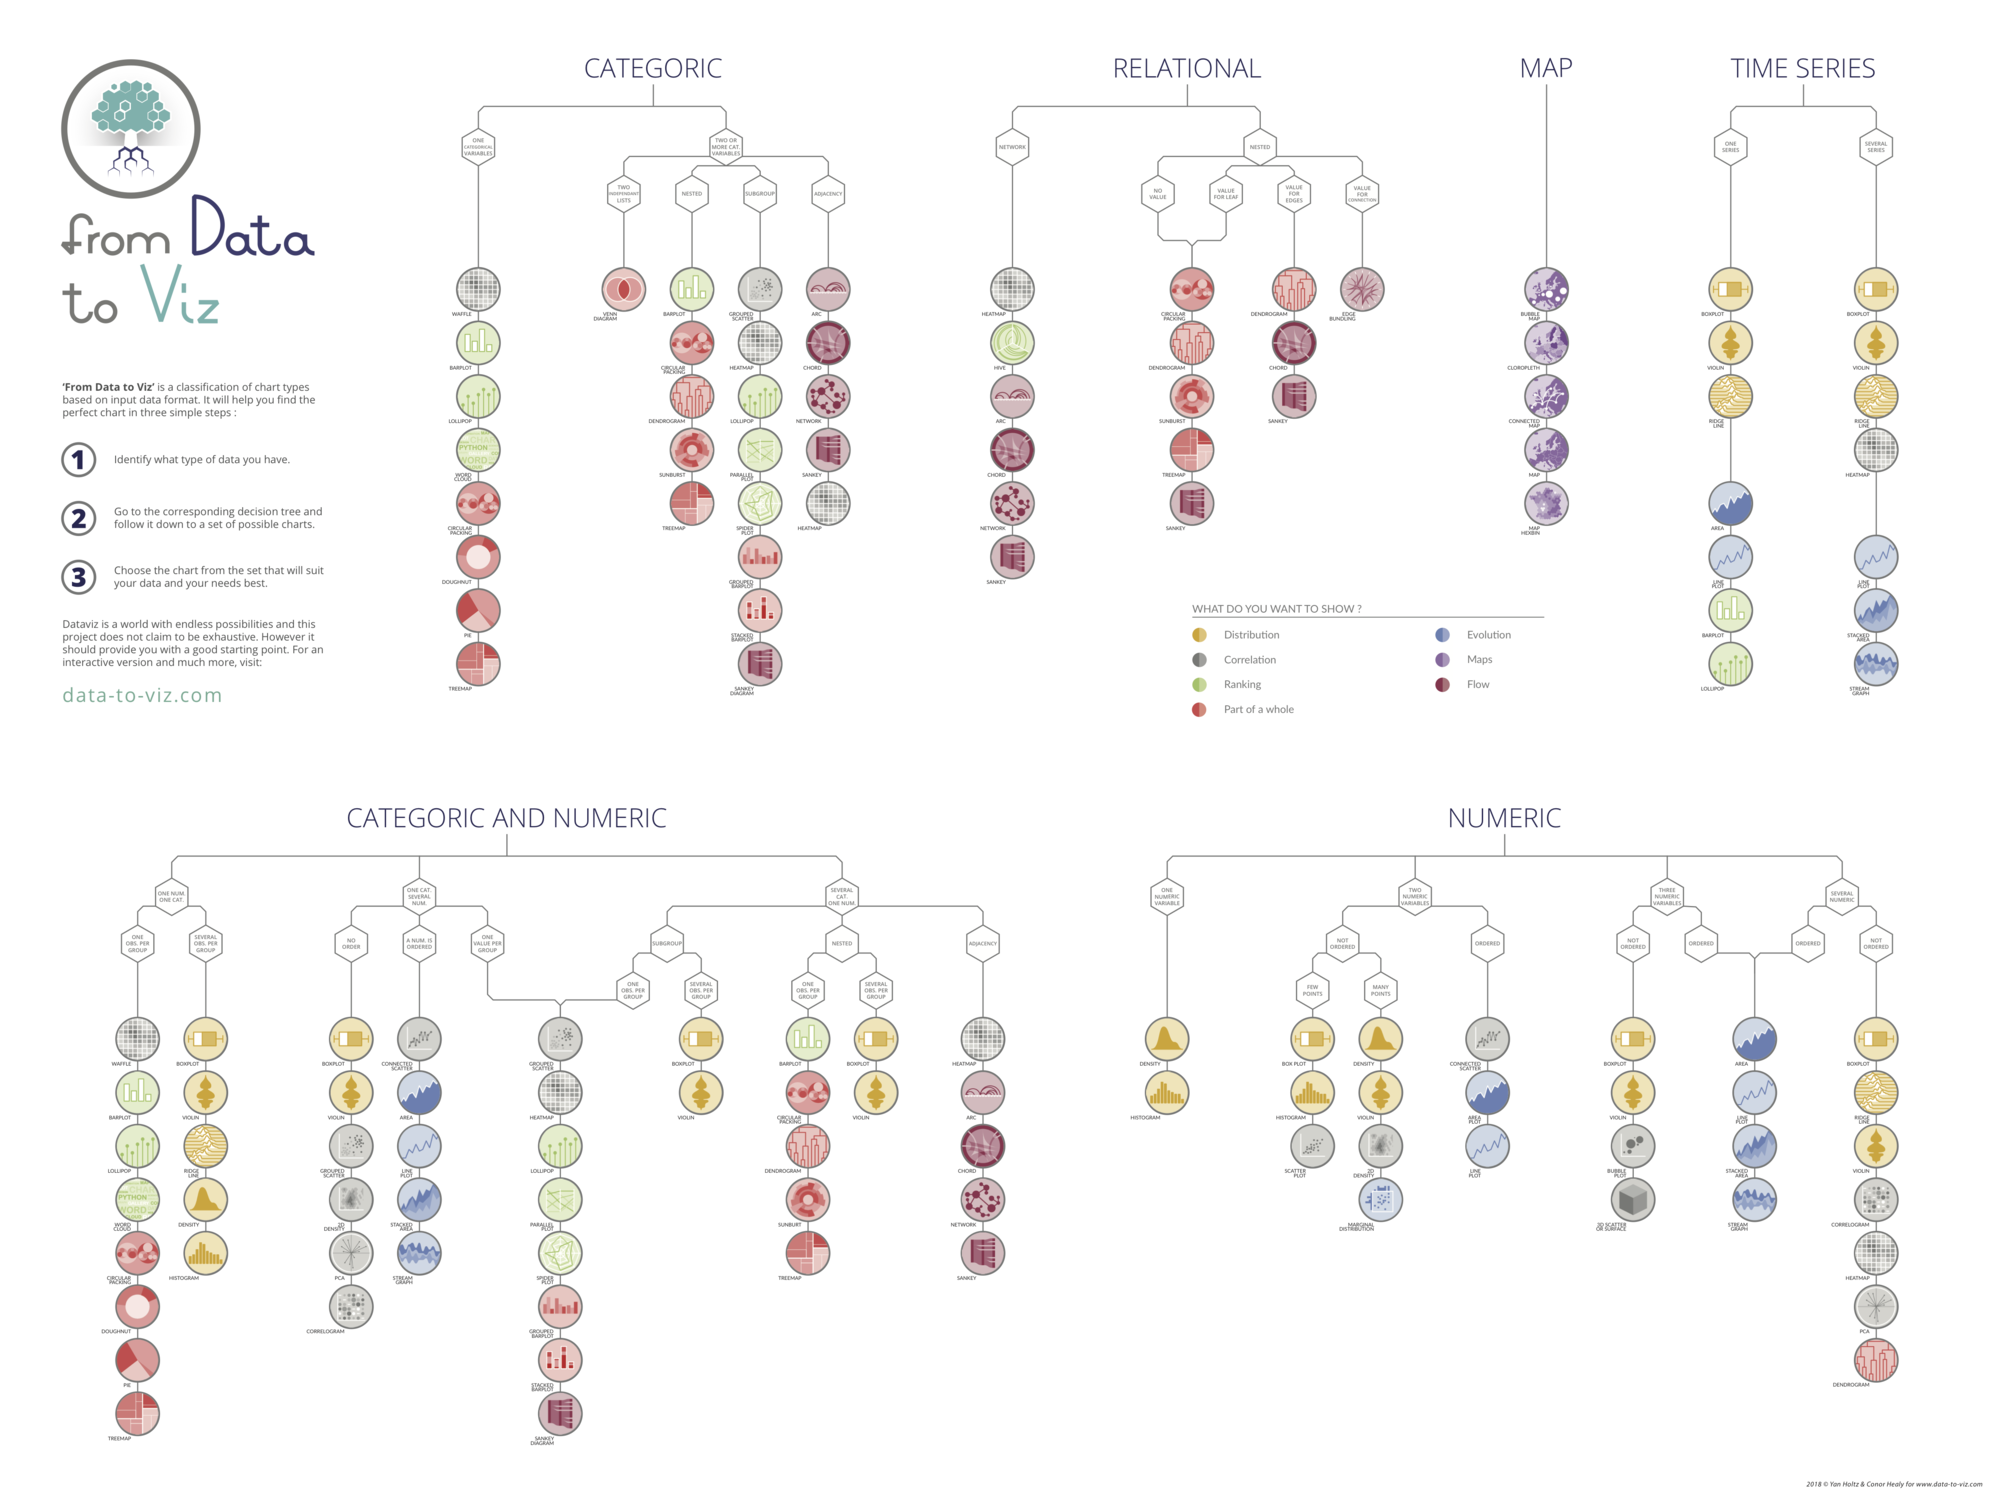


El error más común del analista junior es elegir el gráfico que "se ve más bonito" (como los gráficos de torta en 3D) en lugar del que representa matemáticamente mejor la información.

Herramientas excelentes como [Data-to-Viz](https://www.data-to-viz.com/) proponen un enfoque algorítmico para elegir gráficos a partir de las variables que se tienen (y su tipo). Va un resumen de ejemplo:

*   **1 Variable Numérica:** ¿Se busca ver la distribución? Usar un **Histograma** o un gráfico de **Densidad (KDE)**.
*   **1 Numérica + 1 Categórica:** ¿Queremos comparar grupos? Usar un **Boxplot** (si te importan los cuartiles/outliers) o un **Violin Plot** (si te importa la forma de la distribución).
*   **2 Variables Numéricas:** ¿Buscamos correlación? Usar un **Scatter Plot** (Dispersión).
*   **Evolución Temporal:** ¿Tenemos fechas en el eje X? Usar **Líneas**. *Nunca user gráficos de barras para series de tiempo*, ya que las barras implican cantidades discretas aisladas, mientras que la línea implica continuidad.
*   **Composición (Partes de un todo):** Usar un **Gráfico de Barras Apiladas** o un **Treemap**. *Evita el gráfico de torta (Pie Chart)* si se tienen más de 3 categorías, ya que el cerebro humano es pésimo calculando áreas y ángulos, pero excelente comparando longitudes (barras).


## 2. El Principio del *Data-Ink Ratio*



Acuñado por el estadístico Edward Tufte, el *Data-Ink Ratio* (Ratio Datos-Tinta) establece que **toda la "tinta" (píxeles) de un gráfico debe usarse para representar datos**. Cualquier tinta que no represente datos (bordes gruesos, fondos grises, grillas densas, sombras 3D) es "tinta basura" (*chartjunk*) y debe ser eliminada.

> **Regla de Oro:** Si se puede borrar un elemento del gráfico y la información matemática no se pierde, bórralo.


## 3. Refactoring Visual: De "Feo" a "Ejecutivo"



Vamos a poner esto en práctica. Simulamos los datos de la tasa de fallas de 8 plantas industriales diferentes. Nuestro objetivo es mostrarle al Director de Operaciones que la **Planta Delta** tiene un problema crítico.

### Fase 1: El Gráfico "Por Defecto" (Lo que NO hay que hacer)


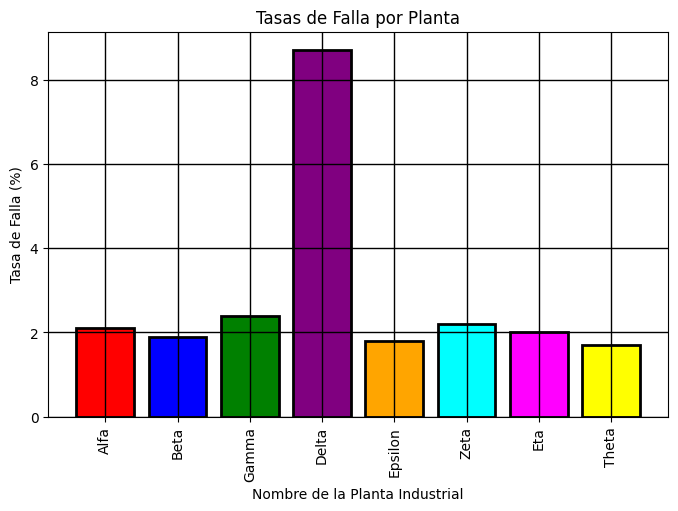

In [4]:
# Generamos datos sintéticos
plantas =['Alfa', 'Beta', 'Gamma', 'Delta', 'Epsilon', 'Zeta', 'Eta', 'Theta']
tasas_falla =[2.1, 1.9, 2.4, 8.7, 1.8, 2.2, 2.0, 1.7]

df_fallas = pd.DataFrame({'Planta': plantas, 'Tasa_Falla_Pct': tasas_falla})

# EL GRÁFICO MALO
plt.figure(figsize=(8, 5))
# Usamos colores aleatorios que no significan nada
colores_aleatorios =['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow']

plt.bar(df_fallas['Planta'], df_fallas['Tasa_Falla_Pct'], color=colores_aleatorios, edgecolor='black', linewidth=2)

plt.title("Tasas de Falla por Planta")
plt.xlabel("Nombre de la Planta Industrial")
plt.ylabel("Tasa de Falla (%)")
plt.grid(True, color='black', linestyle='-', linewidth=1) # Grilla invasiva
plt.xticks(rotation=90) # Etiquetas rotadas difíciles de leer

plt.show()


**Auditoría de Errores (Carga Cognitiva Alta):**
1. **Colores arcoíris:** El cerebro intenta buscar un significado a los colores (¿Rojo es malo? ¿Verde es bueno? ¿Por qué Delta es violeta?). No hay significado, solo confunden.
2. **Orden aleatorio:** Las barras suben y bajan sin lógica. El ojo tiene que saltar de un lado a otro para encontrar el mayor y el menor.
3. **Grilla invasiva:** Las líneas negras de fondo compiten por la atención con las barras de datos.
4. **Etiquetas rotadas:** Obligan al espectador a torcer la cabeza para leer.
5. **Título descriptivo, no informativo:** "Tasas de Falla por Planta" dice *qué* es el gráfico, pero no *qué debo concluir* de él.

### Fase 2: El Gráfico Ejecutivo (Aplicando Ingeniería Visual)



Vamos a refactorizar este gráfico aplicando nuestros principios:
1. **Ordenar los datos:** De mayor a menor.
2. **Barras horizontales:** Para que los nombres de las plantas se lean de izquierda a derecha de forma natural.
3. **Color estratégico:** Todo en gris neutro, excepto la Planta Delta en rojo (nuestro foco de atención).
4. **Eliminar tinta basura:** Fuera bordes, fuera grillas densas, fuera el eje X (ponemos los números directamente en las barras).
5. **Título con mensaje (Storytelling):** El título debe dar la conclusión.

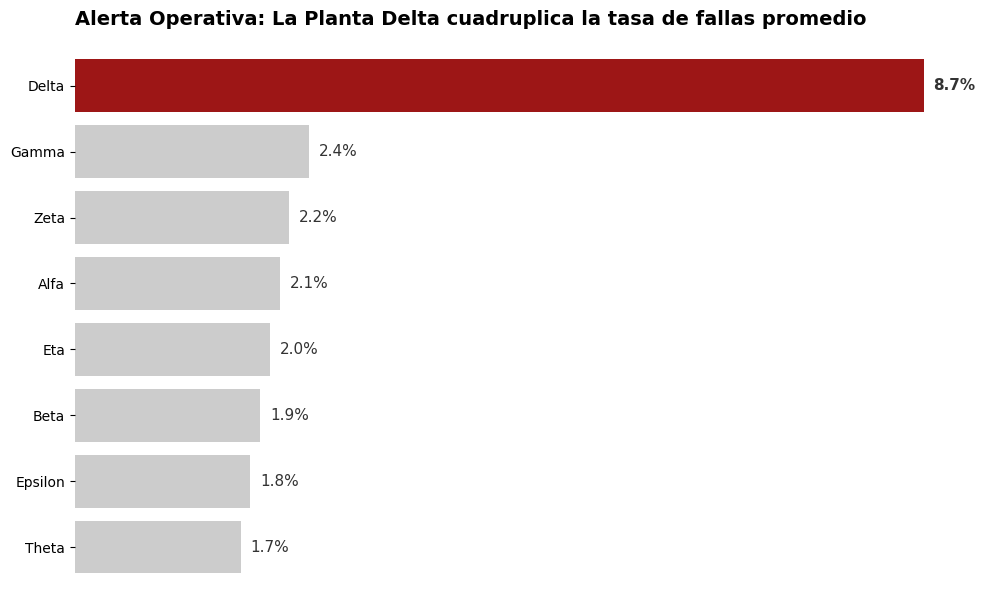

In [5]:
# 1. Ordenamos los datos
df_ordenado = df_fallas.sort_values('Tasa_Falla_Pct', ascending=False).reset_index(drop=True)

# 2. Definimos una paleta estratégica (Gris para lo normal, Rojo oscuro para la anomalía)
# Usamos una lista de comprensión para asignar el color
paleta_estrategica =['#b30000' if planta == 'Delta' else '#cccccc' for planta in df_ordenado['Planta']]

# 3. Creamos el gráfico horizontal
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(
    data=df_ordenado,
    x='Tasa_Falla_Pct',
    y='Planta',
    palette=paleta_estrategica,
    ax=ax
)

# 4. Eliminamos la "tinta basura" (bordes superior, derecho e inferior)
sns.despine(bottom=True, left=True)

# 5. Eliminamos el eje X y su etiqueta (ya que pondremos los valores en las barras)
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('') # El nombre de las plantas es autoexplicativo

# 6. Agregamos las etiquetas de datos directamente al final de cada barra
for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_width() + 0.1, # Posición X (un poco a la derecha de la barra)
        bar.get_y() + bar.get_height() / 2, # Posición Y (centro de la barra)
        f"{df_ordenado['Tasa_Falla_Pct'].iloc[i]}%", # Texto a mostrar
        va='center',
        ha='left',
        fontsize=11,
        color='#333333',
        fontweight='bold' if df_ordenado['Planta'].iloc[i] == 'Delta' else 'normal'
    )

# 7. Título con Storytelling
plt.title(
    "Alerta Operativa: La Planta Delta cuadruplica la tasa de fallas promedio",
    fontsize=14,
    fontweight='bold',
    loc='left',
    pad=20
)

plt.tight_layout()
plt.show()


**Análisis de Ingeniería:**

Observa la diferencia abismal. En este segundo gráfico, el espectador tarda exactamente **0,5 segundos** en entender el problema: Delta está fallando catastróficamente. No hay distracciones, no hay que cruzar la vista con los ejes, y el título ya le da la conclusión al gerente antes de que empiece a analizar los números.


> *Alguien podría reclamar por los "colores", así que...*

## 4. Accesibilidad y Daltonismo



Como ingenieros, diseñamos sistemas para todos. Aproximadamente el `8%` de los hombres y el `0,5%` de las mujeres tienen algún tipo de daltonismo (usualmente dificultad para distinguir entre rojo y verde).

> ⚠️ **Mala práctica:** Usar un semáforo (Rojo = Malo, Verde = Bueno) en un *scatter plot* para diferenciar clases. Un daltónico verá ambos grupos del mismo color (tonos de marrón/gris).

**Soluciones de Ingeniería:**
1. **Paletas seguras:** Utilizar paletas diseñadas para ser perceptualmente uniformes y seguras para daltónicos (como `viridis`, `cividis` o `magma` en matplotlib).
2. **Doble codificación:** No depender solo del color. Si se usa rojo y verde, que el rojo sea un triángulo (`marker='^'`) y el verde un círculo (`marker='o'`). Así, aunque el color no se perciba, la forma geométrica transmite la información. Son ejemplos para ilustrar simplemente...

## Resultados y Discusión



La visualización de datos no es un arte subjetivo, es una ciencia de la comunicación.
- Elegir el gráfico correcto respeta la naturaleza matemática de los datos.
- Reducir el *Data-Ink Ratio* elimina el ruido visual.
- Usar el color estratégicamente dirige la atención del espectador hacia el *insight* de negocio que descubrimos durante nuestro EDA.


> *Un ingeniero que domina Pandas y Scikit-Learn es valioso. Un ingeniero que además sabe comunicar sus hallazgos con claridad ejecutiva, es indispensable.* (me dicen "Romeo" jaja)



## Conexiones y Próximos Pasos


- ➡️ **Siguiente:** Con esto, más que listos para avanzar al **Capítulo 3: Modelos Clásicos de Machine Learning**, donde usaremos estos datos limpios y comprendidos para entrenar algoritmos predictivos.
- 🔄 **Relacionado:** Si se quiere profundizar en cómo elegir gráficos, recomiendo explorar el árbol de decisión interactivo de [Data-to-Viz](https://www.data-to-viz.com/).



## Referencias


1. Tufte, E. R. (2001). *The Visual Display of Quantitative Information*. Graphics Press.
2. Holtz, Y., & Healy, C. (2018). *From Data to Viz*. Recuperado de https://www.data-to-viz.com/
3. Nussbaumer Knaflic, C. (2015). *Storytelling with Data: A Data Visualization Guide for Business Professionals*. Wiley.

---


## Entorno de Ejecución


In [6]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
statsmodels,0.14.6
